# Kaggle diabetes prediction challenge: Submission template

Our lesson 20: classification activity will use an active Kaggle playground competition. Playground competitions run every month and highlight interesting/approachable datasets for the ML community to practice skills on a variety of ML problem types without the pressure, complexity and long duration of prize money competitions. 

It just so happens that this month's playground competition is a classification challenge! See the full competition details here: [Playground Series - Season 5, Episode 12: Diabetes Prediction Challenge](https://www.kaggle.com/competitions/playground-series-s5e12)

This notebook template will help you make your first Kaggle competition submission. It is pre-filled with code to load the competition data and output random predictions (see section 5. Submission below). This will score ~0.50 on the Kaggle public leaderboard. Your job is to improve that score with EDA, clever feature engineering and good model optimization. Good luck!

## How to submit on Kaggle

**1. Upload this notebook to Kaggle:**
   - Create a Kaggle account and log in to [kaggle](https://www.kaggle.com)
   - Click '+ Create' in the left navigation menu
   - Select 'Import Notebook' and upload this file (or link to GitHub)

**2. Start the notebook:**
   - Find your uploaded notebook in your Kaggle account under 'Code'
   - Click on the notebook to open it
   - The notebook will open in edit mode - you can now run cells and make changes

**3. Add the competition dataset:**
   - From the notebook environment, in the right sidebar, click the 'Input' tab
   - Click '+ Add Input' → filter by 'Competition Datasets'
   - Find 'Diabetes Prediction Challenge' and click the '+' icon
   - Note: You must join the competition first (click 'Join Competition' on the competition page)

**4. Access the data:**
   - Once added, the data is available at `/kaggle/input/playground-series-s5e12/`
   - Files: `train.csv` (training data with labels), `test.csv` (test data without labels), `sample_submission.csv` (submission format example)

**5. Make your submission:**
   - Your notebook must output test set predictions to `submission.csv` in the correct format
   - Go to 'Submit to competition' tab in the right sidebar and click 'Submit'

You may see warnings when running on Kaggle due to inconsistencies in installed package versions between your environment and Kaggle. If you are using a virtual environment already, install this [kaggle_requirements.txt](https://github.com/gperdrizet/FSA_devops/blob/main/notebooks/unit3/lesson_20/kaggle_requirements.txt.ipynb):

```
pip install --force-reinstall kaggle_requirements.txt
```

This is working for me with Python 3.12. It contains a slightly newer version of scikit-learn than is found on Kaggle. Update in the Kaggle environment by going to 'Add-ons' -> 'Install Dependencies' and adding:

```
pip install scikit-learn==1.5.2
```

>**Note:** This notebook uses a `KAGGLE` flag (under 'Run >configuration') to switch between Kaggle and local file paths. Set it >to `True` when running on Kaggle, or `False` when running locally.

## Notebook set-up

### Imports

In [1]:
# Standard library imports
from pathlib import Path

# Third party imports
import pandas as pd

### Run configuration

In [2]:
# Set to True when running on Kaggle, False when running locally
KAGGLE = False

### Data loading

In [ ]:
# Set file paths based on environment
if KAGGLE:

    # Kaggle paths - data is in /kaggle/input/
    train_df_path = '/kaggle/input/playground-series-s5e12/train.csv'
    test_df_path = '/kaggle/input/playground-series-s5e12/test.csv'

else:

    # Otherwise, load data from course GitHub repository
    train_df_path = 'https://gperdrizet.github.io/FSA_devops/assets/data/unit3/diabetes_prediction_train.csv'
    test_df_path = 'https://gperdrizet.github.io/FSA_devops/assets/data/unit3/diabetes_prediction_test.csv'

# Load the training and testing datasets
train_df = pd.read_csv(train_df_path)
test_df = pd.read_csv(test_df_path)

# Display first few rows of training data
train_df.head()

,id,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,...,gender,ethnicity,education_level,income_level,smoking_status,employment_status,family_history_diabetes,hypertension_history,cardiovascular_history,diagnosed_diabetes
0,0,31,1,45,7.7,6.8,6.1,33.4,0.93,112,...,Female,Hispanic,Highschool,Lower-Middle,Current,Employed,0,0,0,1.0
1,1,50,2,73,5.7,6.5,5.8,23.8,0.83,120,...,Female,White,Highschool,Upper-Middle,Never,Employed,0,0,0,1.0
2,2,32,3,158,8.5,7.4,9.1,24.1,0.83,95,...,Male,Hispanic,Highschool,Lower-Middle,Never,Retired,0,0,0,0.0
3,3,54,3,77,4.6,7.0,9.2,26.6,0.83,121,...,Female,White,Highschool,Lower-Middle,Current,Employed,0,1,0,1.0
4,4,54,1,55,5.7,6.2,5.1,28.8,0.90,108,...,Male,White,Highschool,Upper-Middle,Never,Retired,0,1,0,1.0


In [4]:
# Display dataset information (columns, dtypes, non-null counts)
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700000 entries, 0 to 699999
Data columns (total 26 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   id                                  700000 non-null  int64  
 1   age                                 700000 non-null  int64  
 2   alcohol_consumption_per_week        700000 non-null  int64  
 3   physical_activity_minutes_per_week  700000 non-null  int64  
 4   diet_score                          700000 non-null  float64
 5   sleep_hours_per_day                 700000 non-null  float64
 6   screen_time_hours_per_day           700000 non-null  float64
 7   bmi                                 700000 non-null  float64
 8   waist_to_hip_ratio                  700000 non-null  float64
 9   systolic_bp                         700000 non-null  int64  
 10  diastolic_bp                        700000 non-null  int64  
 11  heart_rate                

## 1. EDA

Scanning dataframe for missing or bad data
                   id            age  alcohol_consumption_per_week  \
count   700000.000000  700000.000000                 700000.000000   
unique            NaN            NaN                           NaN   
top               NaN            NaN                           NaN   
freq              NaN            NaN                           NaN   
mean    349999.500000      50.359734                      2.072411   
std     202072.738554      11.655520                      1.048189   
min          0.000000      19.000000                      1.000000   
25%     174999.750000      42.000000                      1.000000   
50%     349999.500000      50.000000                      2.000000   
75%     524999.250000      58.000000                      3.000000   
max     699999.000000      89.000000                      9.000000   

        physical_activity_minutes_per_week     diet_score  \
count                        700000.000000  700000.0000

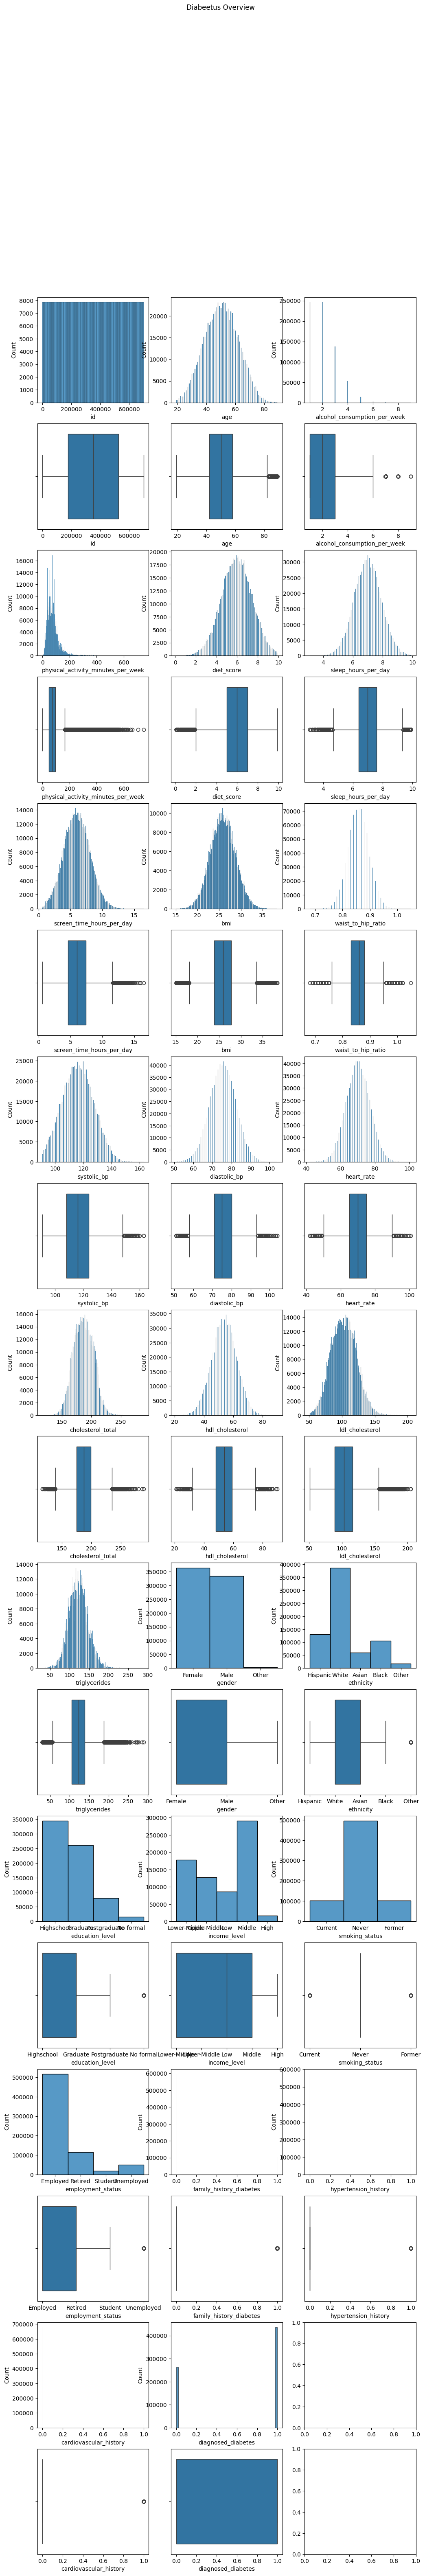

In [5]:
# Your code here...
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys

### Import custom data wrangling module ###
# Build an absolute path from this notebook's parent directory
module_path = os.path.abspath(os.path.join('../../..', 'scripts'))
# Add to sys.path if not already present
if module_path not in sys.path:
    sys.path.append(module_path)

import data_wrangler as dw
### End of custom module import ###

dw.scan_for_bad_data_cells(train_df)
dw.plot_all_data(train_df, name='Diabeetus Overview')


In [6]:
import data_wrangler as dw
# T-test for all numeric columns in a DataFrame
tt_null_rej_cols = dw.simple_ttest_all_data_columns(train_df, alpha=0.05, samples=30)

# Z-test for all numeric columns in a DataFrame
zt_null_rej_cols = dw.ztest_all_data_columns(train_df, alpha=0.05, samples=30)

#Print results
print('T-test rejected null hypothesis for columns:')
for col in tt_null_rej_cols:
    print(f' - {col}')
print('\nZ-test rejected null hypothesis for columns:')
for col in zt_null_rej_cols:
    print(f' - {col}')
    

Starting T-tests...
mean for id: 349999.5
p_value for id: 0.0
Reject null hypothesis for id
mean for age: 50.35973428571429
p_value for age: 0.0
Reject null hypothesis for age
mean for alcohol_consumption_per_week: 2.072411428571429
p_value for alcohol_consumption_per_week: 0.0
Reject null hypothesis for alcohol_consumption_per_week
mean for physical_activity_minutes_per_week: 80.23080285714286
p_value for physical_activity_minutes_per_week: 0.0
Reject null hypothesis for physical_activity_minutes_per_week
mean for diet_score: 5.963694714285714
p_value for diet_score: 0.0
Reject null hypothesis for diet_score
mean for sleep_hours_per_day: 7.002199714285715
p_value for sleep_hours_per_day: 0.0
Reject null hypothesis for sleep_hours_per_day
mean for screen_time_hours_per_day: 6.012733
p_value for screen_time_hours_per_day: 0.0
Reject null hypothesis for screen_time_hours_per_day
mean for bmi: 25.874683899999994
p_value for bmi: 0.0
Reject null hypothesis for bmi
mean for waist_to_hip_rat

f:\AI and Machine Learning course\FSA_devops\.venv\Lib\site-packages\statsmodels\stats\weightstats.py:748: RuntimeWarning: divide by zero encountered in scalar divide
  zstat = (value1 - value2 - diff) / std_diff


## 2. Feature engineering

In [7]:
# Your code here...


## 3. Model building

In [8]:
# Your code here...

## 4. Model evaluation

In [9]:
# Your code here...

## 5. Submission

In [10]:
# Make random predictions for submission by sampling from the training labels
# Note: Replace this with your model's predictions!
predictions = train_df['diagnosed_diabetes'].sample(n=test_df.shape[0], random_state=42).astype(int)
prediction_ids = test_df['id'].astype(int)

# Create submission DataFrame with required format: id, diagnosed_diabetes
submission_df = pd.DataFrame({
    'id': prediction_ids.values,
    'diagnosed_diabetes': predictions.values
})

# Determine output path based on environment
if KAGGLE:

    # On Kaggle, save to current directory for submission
    submission_file = 'submission.csv'

else:

    # Locally, save to ../data/ directory
    # Create directory if it doesn't exist
    data_dir = Path('../data')
    data_dir.mkdir(parents=True, exist_ok=True)
    submission_file = data_dir / 'submission.csv'

# Save submission file and display preview
submission_df.to_csv(submission_file, index=False)
submission_df.head()

,id,diagnosed_diabetes
0,700000,1
1,700001,0
2,700002,1
3,700003,1
4,700004,0
